# **7.3 网络中的网络(NiN)**

之前提到，卷积、池化操作像是一个特征提取器，而在LeNet、AlexNet、VGG中，都是采用一系列卷积层、池化层来提取空间特征结构，然后再用全连接层对“特征的表征”进行处理。但是，全连接层将特征图展平，可能导致对平移性等特点检测的缺失，从而失去对空间的敏感性，完全放弃“表征”结构。

## 7.3.1 NiN块

对此，NiN在每个像素的通道上使用MLP（用$1 \times 1$卷积核实现），增加了非线性，提升了表征能力，构成了多个“微型网络”，并直接抛弃了全连接层。

示意图如下。其中，每一个块由一个卷积层加上两个$1 \times 1$卷积层并加上ReLU函数处理。

![alt text](https://zh-v2.d2l.ai/_images/nin.svg)

NiN块代码实现：



In [1]:
import torch
from torch import nn
from d2l import torch as d2l


def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU())

## 7.3.2 NiN模型

NiN前三层网络结构（卷积层形状和顺序）与AlexNet相似，在每个NiN块后使用MaxPooling层。第四个NiN块输出通道数等于标签类别的数量，并加上一个全局平均汇聚层生成对数概率：

$$
y_k = \frac{1}{H \times W}\sum_{i=i}^{H}\sum_{j=1}^{W} X_k(i, j)
$$
$$
P(class = k | \mathbf{X}) = \frac{\exp(y_k)}{\sum_{j=1}^{K} \exp(y_j)}
$$

虽然NiN显著减少了模型所需的参数量，但实践中训练时间可能会更长。

代码实现：

In [3]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())

In [4]:
##看看形状变化
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


和之前一样，拿$28 \times 28$的图意思意思跑一跑。

loss 0.370, train acc 0.863, test acc 0.851
1252.1 examples/sec on cuda:0


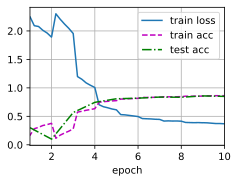

In [5]:
lr, num_epochs, batch_size = 0.1, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

**疑问与思考**
- 为什么要用两个$1 \times 1$卷积？

    一个不足够体现非线性能力和特征提取能力。[这个回答](https://github.com/datawhalechina/d2l-ai-solutions-manual/blob/master/docs/ch07/ch07.md)中有对照试验（一层），`test acc`约为0.553（compared to 0.872 for 2 1x1 conv layer）

- 去除了全连接层后**过拟合明显减少**！`train acc`和`test acc`几乎重合。
- **参数显著减少**。每个卷积层参数量为：
$kernel \times kernel \times channel_{input} \times channel_{output}$

    以第一层为例，第一个nin_block的参数数量为：$11 \times 11 \times 3 \times 96+1 \times 1 \times 96 \times 96+1 \times 1 \times 96 \times 96=53280$

    以此类推，总参数量为：$53280+745472+1179648+34760=2013160$

    compared to $46755168$ for AlexNet(no bias)

    直接比AlexNet少了一个数量级。当然，AlexNet的参数量主要来自于全连接层（约$43000000$，占92%）。

    这个效果在后面的GoogLeNet中亦有体现。
    